In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

### 1.	Write the meta information about the Wine dataset available in the UCI Machine Learning Repository and load the dataset.

In [44]:
column_names = [
    "Class", "Alcohol", "Malic_acid", "Ash", "Alcalinity_of_ash", 
    "Magnesium", "Total_phenols", "Flavanoids", "Nonflavanoid_phenols", 
    "Proanthocyanins", "Color_intensity", "Hue", "OD280_OD315", "Proline"
]
df = pd.read_csv("wine.data", header=None, names=column_names)
print(df.head())

   Class  Alcohol  Malic_acid   Ash  Alcalinity_of_ash  Magnesium  \
0      1    14.23        1.71  2.43               15.6        127   
1      1    13.20        1.78  2.14               11.2        100   
2      1    13.16        2.36  2.67               18.6        101   
3      1    14.37        1.95  2.50               16.8        113   
4      1    13.24        2.59  2.87               21.0        118   

   Total_phenols  Flavanoids  Nonflavanoid_phenols  Proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26             1.28   
2           2.80        3.24                  0.30             2.81   
3           3.85        3.49                  0.24             2.18   
4           2.80        2.69                  0.39             1.82   

   Color_intensity   Hue  OD280_OD315  Proline  
0             5.64  1.04         3.92     1065  
1             4.38  1.05         3.40     1050  
2          

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Class                 178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic_acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Alcalinity_of_ash     178 non-null    float64
 5   Magnesium             178 non-null    int64  
 6   Total_phenols         178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid_phenols  178 non-null    float64
 9   Proanthocyanins       178 non-null    float64
 10  Color_intensity       178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD280_OD315           178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [46]:
df.isnull().sum

<bound method NDFrame._add_numeric_operations.<locals>.sum of      Class  Alcohol  Malic_acid    Ash  Alcalinity_of_ash  Magnesium  \
0    False    False       False  False              False      False   
1    False    False       False  False              False      False   
2    False    False       False  False              False      False   
3    False    False       False  False              False      False   
4    False    False       False  False              False      False   
..     ...      ...         ...    ...                ...        ...   
173  False    False       False  False              False      False   
174  False    False       False  False              False      False   
175  False    False       False  False              False      False   
176  False    False       False  False              False      False   
177  False    False       False  False              False      False   

     Total_phenols  Flavanoids  Nonflavanoid_phenols  Proanthocyanins  \


In [47]:
df.describe

<bound method NDFrame.describe of      Class  Alcohol  Malic_acid   Ash  Alcalinity_of_ash  Magnesium  \
0        1    14.23        1.71  2.43               15.6        127   
1        1    13.20        1.78  2.14               11.2        100   
2        1    13.16        2.36  2.67               18.6        101   
3        1    14.37        1.95  2.50               16.8        113   
4        1    13.24        2.59  2.87               21.0        118   
..     ...      ...         ...   ...                ...        ...   
173      3    13.71        5.65  2.45               20.5         95   
174      3    13.40        3.91  2.48               23.0        102   
175      3    13.27        4.28  2.26               20.0        120   
176      3    13.17        2.59  2.37               20.0        120   
177      3    14.13        4.10  2.74               24.5         96   

     Total_phenols  Flavanoids  Nonflavanoid_phenols  Proanthocyanins  \
0             2.80        3.06          

### 2.	Tabulate the statistical distribution of all numeric variables.

In [48]:
stats_df = df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
stats_df = stats_df.rename(columns={'50%': 'median'})
print(stats_df.to_string())

                      count        mean         std     min   median      max
Class                 178.0    1.938202    0.775035    1.00    2.000     3.00
Alcohol               178.0   13.000618    0.811827   11.03   13.050    14.83
Malic_acid            178.0    2.336348    1.117146    0.74    1.865     5.80
Ash                   178.0    2.366517    0.274344    1.36    2.360     3.23
Alcalinity_of_ash     178.0   19.494944    3.339564   10.60   19.500    30.00
Magnesium             178.0   99.741573   14.282484   70.00   98.000   162.00
Total_phenols         178.0    2.295112    0.625851    0.98    2.355     3.88
Flavanoids            178.0    2.029270    0.998859    0.34    2.135     5.08
Nonflavanoid_phenols  178.0    0.361854    0.124453    0.13    0.340     0.66
Proanthocyanins       178.0    1.590899    0.572359    0.41    1.555     3.58
Color_intensity       178.0    5.058090    2.318286    1.28    4.690    13.00
Hue                   178.0    0.957449    0.228572    0.48    0

### 3.	Visualize the distribution of the numeric variables using histograms

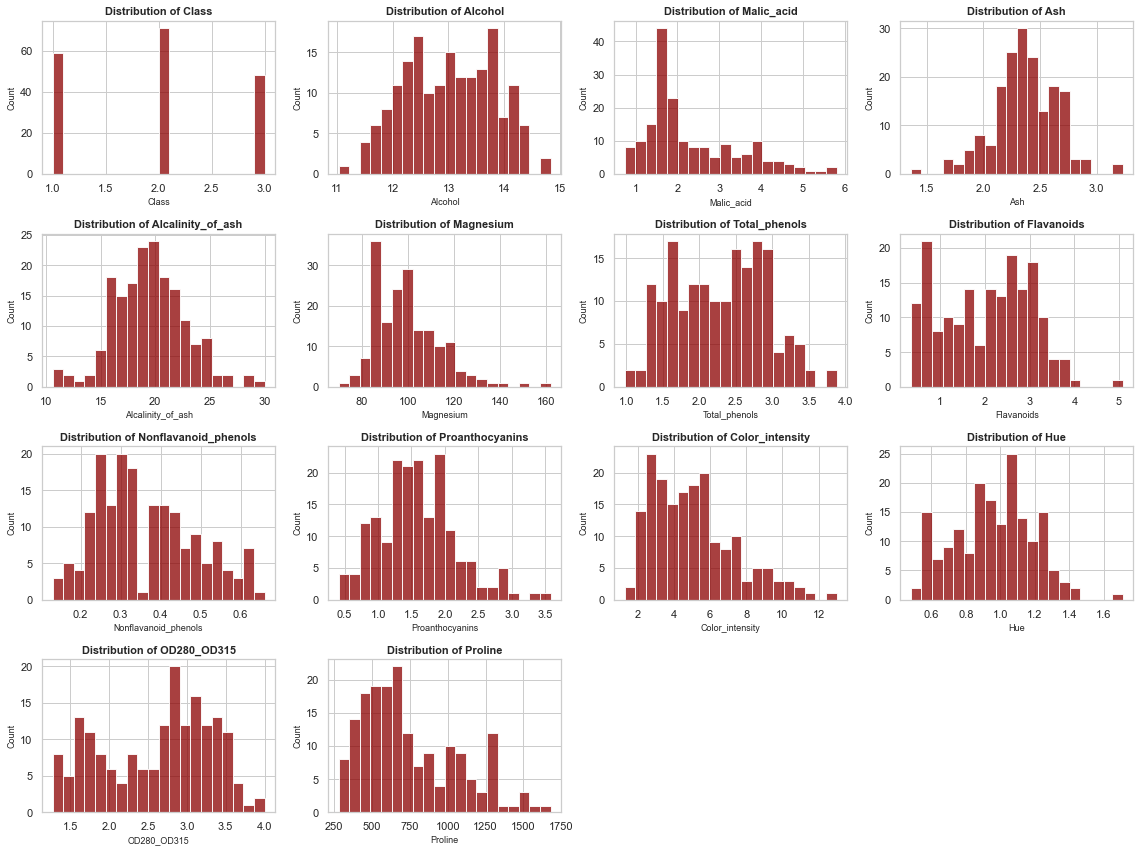

In [49]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=False, ax=axes[i], color='darkred', bins=20)
    axes[i].set_title(f"Distribution of {col}", fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('Count', fontsize=9)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 4.	Perform a stratified 70:30 training-testing split. 

In [50]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    stratify=y, 
    random_state=42
)

print(f"Training set shape (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Testing set shape (X_test, y_test): {X_test.shape}, {y_test.shape}")
print("\nTraining set class proportions:")
print(y_train.value_counts(normalize=True))
print("\nTesting set class proportions:")
print(y_test.value_counts(normalize=True))

Training set shape (X_train, y_train): (124, 13), (124,)
Testing set shape (X_test, y_test): (54, 13), (54,)

Training set class proportions:
2    0.403226
1    0.330645
3    0.266129
Name: Class, dtype: float64

Testing set class proportions:
2    0.388889
1    0.333333
3    0.277778
Name: Class, dtype: float64


### 5.	Standardize the input features using StandardScaler.

In [51]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(X_train_scaled.head())

      Alcohol  Malic_acid       Ash  Alcalinity_of_ash  Magnesium  \
12   0.982686   -0.527640  0.173598          -1.087543  -0.727661   
30   0.957937   -0.745511  1.255504           0.839386   0.063252   
36   0.401078   -0.612894  1.777803          -1.235769   0.656436   
31   0.772317   -0.593949 -0.012937          -0.168547   0.392799   
120 -1.863482    0.107025  0.210905           0.098259  -0.266295   

     Total_phenols  Flavanoids  Nonflavanoid_phenols  Proanthocyanins  \
12        0.491455    0.791460             -0.596717         0.354587   
30        1.131923    1.306553             -0.596717         1.343233   
36        0.491455    0.707363             -0.170491        -0.425924   
31        0.907759    1.243480             -1.193434         0.597412   
120       0.971806    0.822996             -0.340981         0.389276   

     Color_intensity       Hue  OD280_OD315   Proline  
12          0.255419  0.857462     0.437825  1.863180  
30          0.297587  1.032095    

### 6.	Build an MLP classifier with three hidden layers, each containing 13 neurons, and max_iter=500.

In [52]:
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(13, 13, 13), 
    max_iter=500, 
    random_state=42
)

mlp_clf.fit(X_train_scaled, y_train)
y_pred = mlp_clf.predict(X_test_scaled)

### 7.	Use the trained MLP to predict the test samples and calculate classification accuracy.

In [53]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.4f}")


Test Set Accuracy: 0.9815


### 8.	Tabulate precision, recall, and F1-score for all three wine classes. 

In [54]:
classes = sorted(y_test.unique())

# Calculate metrics separately for each class
data = []
for c in classes:
    p = precision_score(y_test, y_pred, labels=[c], average=None, zero_division=0)[0]
    r = recall_score(y_test, y_pred, labels=[c], average=None, zero_division=0)[0]
    f1 = f1_score(y_test, y_pred, labels=[c], average=None, zero_division=0)[0]
    support = (y_test == c).sum()
    
    data.append({
        'Class': c,
        'precision': p,
        'recall': r,
        'f1-score': f1,
        'support': support
    })

# Create a DataFrame and set Class as the index
df_classes = pd.DataFrame(data).set_index('Class')

# Display the final metrics table
print(df_classes.to_markdown())

|   Class |   precision |   recall |   f1-score |   support |
|--------:|------------:|---------:|-----------:|----------:|
|       1 |      1      | 1        |   1        |        18 |
|       2 |      1      | 0.952381 |   0.97561  |        21 |
|       3 |      0.9375 | 1        |   0.967742 |        15 |


### 9.	 Generate and interpret the confusion matrix of the MLP classifier. 

In [55]:
print(confusion_matrix(y_test, y_pred))

[[18  0  0]
 [ 0 20  1]
 [ 0  0 15]]


- Class 1 (18 samples) and Class 3 (15 samples) were classified with 100% accuracy.
- Class 2 had 20 out of 21 samples correct, with a single instance misclassified as Class 3.

### 10.	Display the weights and biases learned by the MLP after training. 

In [56]:
for i, coef in enumerate(mlp_clf.coefs_):
    print(f"Layer {i} to Layer {i+1} Weights Shape: {coef.shape}")

for i, intercept in enumerate(mlp_clf.intercepts_):
    print(f"Layer {i+1} Biases Shape: {intercept.shape}")
    
print("\nFirst layer weights:\n", mlp_clf.coefs_[0])
print("\nSecond layer weights:\n", mlp_clf.coefs_[1])
print("\nThird layer weights:\n", mlp_clf.coefs_[2])
print("\nFourth layer weights:\n", mlp_clf.coefs_[3])
print("\nFirst layer biases:\n", mlp_clf.intercepts_[0])
print("\nSecond layer biases:\n", mlp_clf.intercepts_[1])
print("\nThird layer biases:\n", mlp_clf.intercepts_[2])
print("\nFourth layer biases:\n", mlp_clf.intercepts_[3])

Layer 0 to Layer 1 Weights Shape: (13, 13)
Layer 1 to Layer 2 Weights Shape: (13, 13)
Layer 2 to Layer 3 Weights Shape: (13, 13)
Layer 3 to Layer 4 Weights Shape: (13, 3)
Layer 1 Biases Shape: (13,)
Layer 2 Biases Shape: (13,)
Layer 3 Biases Shape: (13,)
Layer 4 Biases Shape: (3,)

First layer weights:
 [[-2.79537933e-02  5.55085187e-01  1.50399427e-01  2.21898181e-01
  -4.54042393e-01 -5.27106758e-01 -4.15245138e-01  5.19329659e-01
  -1.29904272e-01  3.59212196e-01 -6.22660384e-01  5.57106612e-01
   2.70758690e-01]
 [-3.17800179e-01 -1.34549637e-01 -1.04967098e-01 -1.82412493e-01
   1.30066203e-02 -2.07496026e-01 -1.41059622e-01  3.11278088e-01
  -5.02844724e-01 -1.45750837e-01 -2.83955934e-01 -4.33100371e-02
   4.60495320e-01]
 [-1.60898540e-01  1.69259657e-01  2.95446353e-01 -4.11580016e-01
  -3.89325036e-02 -3.69554992e-01 -3.89576439e-01  5.95397594e-01
   2.28699408e-01  3.28530601e-01 -2.94057652e-01 -2.69125071e-01
   1.65250270e-01]
 [-1.98887703e-01 -2.36673995e-01  1.4879912

### 11.	Plot the MLP training loss curve and analyze model convergence.

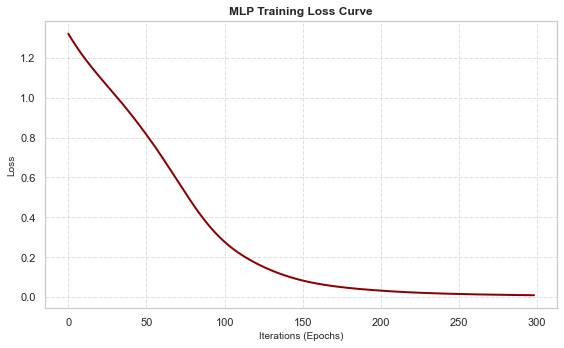

In [57]:
plt.figure(figsize=(8, 5))
plt.plot(mlp_clf.loss_curve_, color='darkred', linewidth=2)
plt.title("MLP Training Loss Curve", fontsize=12, fontweight='bold')
plt.xlabel("Iterations (Epochs)", fontsize=10)
plt.ylabel("Loss", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()